In [ ]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import warnings
from datetime import datetime
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.nn import init

import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
from einops.layers.torch import Rearrange
from scipy.stats import norm
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm, tqdm_notebook, trange

import deepul.pytorch_util as ptu
from deepul.hw3_helper import *
from deepul.hw3_utils.lpips import LPIPS

warnings.filterwarnings('ignore')
ptu.set_gpu_mode(True)
import torch
import torch.nn as nn
from torch.nn import init
import functools
from torch.optim import lr_scheduler
# example usage of the LPIPS loss
from abc import ABC
import itertools

import random
import torch
class Identity(nn.Module):
    def forward(self, x):
        return x
    
import os
import torch
from collections import OrderedDict
from abc import ABC, abstractmethod

loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth


# Question 4 (Bonus): CycleGAN [20pt]
In this question, you'll train a CycleGAN model to learn to translate between two different image domains, without any paired data. Execute the following cell to visualize our two datasets: MNIST and Colored MNIST. 

In [5]:
# visualize_cyclegan_datasets()

In [CycleGAN](https://arxiv.org/pdf/1703.10593.pdf), the goal is to learn functions $F$ and $G$ that can transform images from $X \rightarrow Y$ and vice-versa. This is an unconstrained problem, so we additionally enforce the *cycle-consistency* property, where we want 
$$x \approx G(F(x))$$
and  
$$y \approx F(G(x))$$
This loss function encourages $F$ and $G$ to approximately invert each other. In addition to this cycle-consistency loss, we also have a standard GAN loss such that $F(x)$ and $G(y)$ look like real images from the other domain. 

Since this is a bonus question, we won't do much hand-holding. We recommend reading through the original paper to get a sense of what architectures and hyperparameters are useful. Note that our datasets are fairly simple, so you won't need excessively large models. 

**You will report the following deliverables**
1. A set of images showing real MNIST digits, transformations of those images into Colored MNIST digits, and reconstructions back into the greyscale domain. 
2. A set of images showing real Colored MNIST digits, transformations of those images, and reconstructions. 

## Solution

In [6]:
class ResnetBlock(nn.Module):
    """Define a Resnet block"""

    def __init__(self, dim, padding_type, norm_layer, use_dropout, use_bias):
        """Initialize the Resnet block

        A resnet block is a conv block with skip connections
        We construct a conv block with build_conv_block function,
        and implement skip connections in <forward> function.
        Original Resnet paper: https://arxiv.org/pdf/1512.03385.pdf
        """
        super(ResnetBlock, self).__init__()
        self.conv_block = self.build_conv_block(dim, padding_type, norm_layer, use_dropout, use_bias)

    def build_conv_block(self, dim, padding_type, norm_layer, use_dropout, use_bias):
        """Construct a convolutional block.

        Parameters:
            dim (int)           -- the number of channels in the conv layer.
            padding_type (str)  -- the name of padding layer: reflect | replicate | zero
            norm_layer          -- normalization layer
            use_dropout (bool)  -- if use dropout layers.
            use_bias (bool)     -- if the conv layer uses bias or not

        Returns a conv block (with a conv layer, a normalization layer, and a non-linearity layer (ReLU))
        """
        conv_block = []
        p = 0
        if padding_type == 'reflect':
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == 'replicate':
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == 'zero':
            p = 1
        else:
            raise NotImplementedError('padding [%s] is not implemented' % padding_type)

        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), norm_layer(dim), nn.ReLU(True)]
        if use_dropout:
            conv_block += [nn.Dropout(0.5)]

        p = 0
        if padding_type == 'reflect':
            conv_block += [nn.ReflectionPad2d(1)]
        elif padding_type == 'replicate':
            conv_block += [nn.ReplicationPad2d(1)]
        elif padding_type == 'zero':
            p = 1
        else:
            raise NotImplementedError('padding [%s] is not implemented' % padding_type)
        conv_block += [nn.Conv2d(dim, dim, kernel_size=3, padding=p, bias=use_bias), norm_layer(dim)]

        return nn.Sequential(*conv_block)

    def forward(self, x):
        """Forward function (with skip connections)"""
        out = x + self.conv_block(x)  # add skip connections
        return out

In [7]:
class ResnetGenerator(nn.Module):
    """Resnet-based generator that consists of Resnet blocks between a few downsampling/upsampling operations.

    We adapt Torch code and idea from Justin Johnson's neural style transfer project(https://github.com/jcjohnson/fast-neural-style)
    """

    def __init__(self, input_nc, output_nc, ngf=64, norm_layer=nn.BatchNorm2d, use_dropout=False, n_blocks=6, padding_type='reflect'):
        """Construct a Resnet-based generator

        Parameters:
            input_nc (int)      -- the number of channels in input images
            output_nc (int)     -- the number of channels in output images
            ngf (int)           -- the number of filters in the last conv layer
            norm_layer          -- normalization layer
            use_dropout (bool)  -- if use dropout layers
            n_blocks (int)      -- the number of ResNet blocks
            padding_type (str)  -- the name of padding layer in conv layers: reflect | replicate | zero
        """
        assert(n_blocks >= 0)
        super(ResnetGenerator, self).__init__()
        if type(norm_layer) == functools.partial:
            use_bias = norm_layer.func == nn.InstanceNorm2d
        else:
            use_bias = norm_layer == nn.InstanceNorm2d

        model = [nn.ReflectionPad2d(3),
                 nn.Conv2d(input_nc, ngf, kernel_size=7, padding=0, bias=use_bias),
                 norm_layer(ngf),
                 nn.ReLU(True)]

        n_downsampling = 2
        for i in range(n_downsampling):  # add downsampling layers
            mult = 2 ** i
            model += [nn.Conv2d(ngf * mult, ngf * mult * 2, kernel_size=3, stride=2, padding=1, bias=use_bias),
                      norm_layer(ngf * mult * 2),
                      nn.ReLU(True)]

        mult = 2 ** n_downsampling
        for i in range(n_blocks):       # add ResNet blocks

            model += [ResnetBlock(ngf * mult, padding_type=padding_type, norm_layer=norm_layer, use_dropout=use_dropout, use_bias=use_bias)]

        for i in range(n_downsampling):  # add upsampling layers
            mult = 2 ** (n_downsampling - i)
            model += [nn.ConvTranspose2d(ngf * mult, int(ngf * mult / 2),
                                         kernel_size=3, stride=2,
                                         padding=1, output_padding=1,
                                         bias=use_bias),
                      norm_layer(int(ngf * mult / 2)),
                      nn.ReLU(True)]
        model += [nn.ReflectionPad2d(3)]
        model += [nn.Conv2d(ngf, output_nc, kernel_size=7, padding=0)]
        model += [nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, input):
        """Standard forward"""
        return self.model(input)

In [8]:
class NLayerDiscriminator(nn.Module):
    """Defines a PatchGAN discriminator"""

    def __init__(self, input_nc, ndf=64, n_layers=3, norm_layer=nn.BatchNorm2d):
        """Construct a PatchGAN discriminator

        Parameters:
            input_nc (int)  -- the number of channels in input images
            ndf (int)       -- the number of filters in the last conv layer
            n_layers (int)  -- the number of conv layers in the discriminator
            norm_layer      -- normalization layer
        """
        super(NLayerDiscriminator, self).__init__()
        if type(norm_layer) == functools.partial:  # no need to use bias as BatchNorm2d has affine parameters
            use_bias = norm_layer.func == nn.InstanceNorm2d
        else:
            use_bias = norm_layer == nn.InstanceNorm2d

        kw = 4
        padw = 1
        sequence = [nn.Conv2d(input_nc, ndf, kernel_size=kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        nf_mult = 1
        nf_mult_prev = 1
        for n in range(1, n_layers):  # gradually increase the number of filters
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=use_bias),
                norm_layer(ndf * nf_mult),
                nn.LeakyReLU(0.2, True)
            ]

        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n_layers, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=use_bias),
            norm_layer(ndf * nf_mult),
            nn.LeakyReLU(0.2, True)
        ]

        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]  # output 1 channel prediction map
        self.model = nn.Sequential(*sequence)

    def forward(self, input):
        """Standard forward."""
        return self.model(input)


In [9]:
def init_weights(net, init_type='normal', init_gain=0.02):
    """Initialize network weights.

    Parameters:
        net (network)   -- network to be initialized
        init_type (str) -- the name of an initialization method: normal | xavier | kaiming | orthogonal
        init_gain (float)    -- scaling factor for normal, xavier and orthogonal.

    We use 'normal' in the original pix2pix and CycleGAN paper. But xavier and kaiming might
    work better for some applications. Feel free to try yourself.
    """
    def init_func(m):  # define the initialization function
        classname = m.__class__.__name__
        if hasattr(m, 'weight') and (classname.find('Conv') != -1 or classname.find('Linear') != -1):
            if init_type == 'normal':
                init.normal_(m.weight.data, 0.0, init_gain)
            elif init_type == 'xavier':
                init.xavier_normal_(m.weight.data, gain=init_gain)
            elif init_type == 'kaiming':
                init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
            elif init_type == 'orthogonal':
                init.orthogonal_(m.weight.data, gain=init_gain)
            else:
                raise NotImplementedError('initialization method [%s] is not implemented' % init_type)
            if hasattr(m, 'bias') and m.bias is not None:
                init.constant_(m.bias.data, 0.0)
        elif classname.find('BatchNorm2d') != -1:  # BatchNorm Layer's weight is not a matrix; only normal distribution applies.
            init.normal_(m.weight.data, 1.0, init_gain)
            init.constant_(m.bias.data, 0.0)

    print('initialize network with %s' % init_type)
    net.apply(init_func)  # apply the initialization function <init_func>

In [10]:
def get_norm_layer(norm_type='instance'):
    """Return a normalization layer

    Parameters:
        norm_type (str) -- the name of the normalization layer: batch | instance | none

    For BatchNorm, we use learnable affine parameters and track running statistics (mean/stddev).
    For InstanceNorm, we do not use learnable affine parameters. We do not track running statistics.
    """
    if norm_type == 'batch':
        norm_layer = functools.partial(nn.BatchNorm2d, affine=True, track_running_stats=True)
    elif norm_type == 'instance':
        norm_layer = functools.partial(nn.InstanceNorm2d, affine=False, track_running_stats=False)
    elif norm_type == 'none':
        def norm_layer(x):
            return Identity()
    else:
        raise NotImplementedError('normalization layer [%s] is not found' % norm_type)
    return norm_layer


In [11]:
def init_net(net, init_type='normal', init_gain=0.02, gpu_ids=[]):
    """Initialize a network: 1. register CPU/GPU device (with multi-GPU support); 2. initialize the network weights
    Parameters:
        net (network)      -- the network to be initialized
        init_type (str)    -- the name of an initialization method: normal | xavier | kaiming | orthogonal
        gain (float)       -- scaling factor for normal, xavier and orthogonal.
        gpu_ids (int list) -- which GPUs the network runs on: e.g., 0,1,2

    Return an initialized network.
    """
    if len(gpu_ids) > 0:
        assert(torch.cuda.is_available())
        net.to(gpu_ids[0])
        # net = torch.nn.DataParallel(net, gpu_ids)  # multi-GPUs
    init_weights(net, init_type, init_gain=init_gain)
    return net

In [12]:
def define_G(input_nc, output_nc, ngf, netG, norm='batch', use_dropout=False, init_type='normal', init_gain=0.02, gpu_ids=[]):
    """Create a generator

    Parameters:
        input_nc (int) -- the number of channels in input images
        output_nc (int) -- the number of channels in output images
        ngf (int) -- the number of filters in the last conv layer
        netG (str) -- the architecture's name: resnet_9blocks | resnet_6blocks | unet_256 | unet_128
        norm (str) -- the name of normalization layers used in the network: batch | instance | none
        use_dropout (bool) -- if use dropout layers.
        init_type (str)    -- the name of our initialization method.
        init_gain (float)  -- scaling factor for normal, xavier and orthogonal.
        gpu_ids (int list) -- which GPUs the network runs on: e.g., 0,1,2

    Returns a generator

    Our current implementation provides two types of generators:
        U-Net: [unet_128] (for 128x128 input images) and [unet_256] (for 256x256 input images)
        The original U-Net paper: https://arxiv.org/abs/1505.04597

        Resnet-based generator: [resnet_6blocks] (with 6 Resnet blocks) and [resnet_9blocks] (with 9 Resnet blocks)
        Resnet-based generator consists of several Resnet blocks between a few downsampling/upsampling operations.
        We adapt Torch code from Justin Johnson's neural style transfer project (https://github.com/jcjohnson/fast-neural-style).


    The generator has been initialized by <init_net>. It uses RELU for non-linearity.
    """
    net = None
    norm_layer = get_norm_layer(norm_type=norm)

    net = ResnetGenerator(input_nc, output_nc, ngf, norm_layer=norm_layer, use_dropout=use_dropout, n_blocks=9)
    return init_net(net, init_type, init_gain, gpu_ids)

In [13]:
def get_scheduler(optimizer, opt):
    """Return a learning rate scheduler

    Parameters:
        optimizer          -- the optimizer of the network
        opt (option class) -- stores all the experiment flags; needs to be a subclass of BaseOptions．　
                              opt.lr_policy is the name of learning rate policy: linear | step | plateau | cosine

    For 'linear', we keep the same learning rate for the first <opt.n_epochs> epochs
    and linearly decay the rate to zero over the next <opt.n_epochs_decay> epochs.
    For other schedulers (step, plateau, and cosine), we use the default PyTorch schedulers.
    See https://pytorch.org/docs/stable/optim.html for more details.
    """
    if opt.lr_policy == 'linear':
        def lambda_rule(epoch):
            lr_l = 1.0 - max(0, epoch + opt.epoch_count - opt.n_epochs) / float(opt.n_epochs_decay + 1)
            return lr_l
        scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_rule)
    elif opt.lr_policy == 'step':
        scheduler = lr_scheduler.StepLR(optimizer, step_size=opt.lr_decay_iters, gamma=0.1)
    elif opt.lr_policy == 'plateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, threshold=0.01, patience=5)
    elif opt.lr_policy == 'cosine':
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt.n_epochs, eta_min=0)
    else:
        return NotImplementedError('learning rate policy [%s] is not implemented', opt.lr_policy)
    return scheduler


In [14]:
def define_D(input_nc, ndf, netD, n_layers_D=3, norm='batch', init_type='normal', init_gain=0.02, gpu_ids=[]):
    """Create a discriminator

    Parameters:
        input_nc (int)     -- the number of channels in input images
        ndf (int)          -- the number of filters in the first conv layer
        netD (str)         -- the architecture's name: basic | n_layers | pixel
        n_layers_D (int)   -- the number of conv layers in the discriminator; effective when netD=='n_layers'
        norm (str)         -- the type of normalization layers used in the network.
        init_type (str)    -- the name of the initialization method.
        init_gain (float)  -- scaling factor for normal, xavier and orthogonal.
        gpu_ids (int list) -- which GPUs the network runs on: e.g., 0,1,2

    Returns a discriminator

    Our current implementation provides three types of discriminators:
        [basic]: 'PatchGAN' classifier described in the original pix2pix paper.
        It can classify whether 70×70 overlapping patches are real or fake.
        Such a patch-level discriminator architecture has fewer parameters
        than a full-image discriminator and can work on arbitrarily-sized images
        in a fully convolutional fashion.

        [n_layers]: With this mode, you can specify the number of conv layers in the discriminator
        with the parameter <n_layers_D> (default=3 as used in [basic] (PatchGAN).)

        [pixel]: 1x1 PixelGAN discriminator can classify whether a pixel is real or not.
        It encourages greater color diversity but has no effect on spatial statistics.

    The discriminator has been initialized by <init_net>. It uses Leakly RELU for non-linearity.
    """
    net = None
    norm_layer = get_norm_layer(norm_type=norm)

    if netD == 'basic':  # default PatchGAN classifier
        net = NLayerDiscriminator(input_nc, ndf, n_layers=3, norm_layer=norm_layer)
    else:
        raise NotImplementedError('Discriminator model name [%s] is not recognized' % netD)
    return init_net(net, init_type, init_gain, gpu_ids)

In [15]:
class ImagePool():
    """This class implements an image buffer that stores previously generated images.

    This buffer enables us to update discriminators using a history of generated images
    rather than the ones produced by the latest generators.
    """

    def __init__(self, pool_size):
        """Initialize the ImagePool class

        Parameters:
            pool_size (int) -- the size of image buffer, if pool_size=0, no buffer will be created
        """
        self.pool_size = pool_size
        if self.pool_size > 0:  # create an empty pool
            self.num_imgs = 0
            self.images = []

    def query(self, images):
        """Return an image from the pool.

        Parameters:
            images: the latest generated images from the generator

        Returns images from the buffer.

        By 50/100, the buffer will return input images.
        By 50/100, the buffer will return images previously stored in the buffer,
        and insert the current images to the buffer.
        """
        if self.pool_size == 0:  # if the buffer size is 0, do nothing
            return images
        return_images = []
        for image in images:
            image = torch.unsqueeze(image.data, 0)
            if self.num_imgs < self.pool_size:   # if the buffer is not full; keep inserting current images to the buffer
                self.num_imgs = self.num_imgs + 1
                self.images.append(image)
                return_images.append(image)
            else:
                p = random.uniform(0, 1)
                if p > 0.5:  # by 50% chance, the buffer will return a previously stored image, and insert the current image into the buffer
                    random_id = random.randint(0, self.pool_size - 1)  # randint is inclusive
                    tmp = self.images[random_id].clone()
                    self.images[random_id] = image
                    return_images.append(tmp)
                else:       # by another 50% chance, the buffer will return the current image
                    return_images.append(image)
        return_images = torch.cat(return_images, 0)   # collect all the images and return
        return return_images

In [16]:
class BaseModel(ABC):
    """This class is an abstract base class (ABC) for models.
    To create a subclass, you need to implement the following five functions:
        -- <__init__>:                      initialize the class; first call BaseModel.__init__(self, opt).
        -- <set_input>:                     unpack data from dataset and apply preprocessing.
        -- <forward>:                       produce intermediate results.
        -- <optimize_parameters>:           calculate losses, gradients, and update network weights.
        -- <modify_commandline_options>:    (optionally) add model-specific options and set default options.
    """

    def __init__(self, opt):
        """Initialize the BaseModel class.

        Parameters:
            opt (Option class)-- stores all the experiment flags; needs to be a subclass of BaseOptions

        When creating your custom class, you need to implement your own initialization.
        In this function, you should first call <BaseModel.__init__(self, opt)>
        Then, you need to define four lists:
            -- self.loss_names (str list):          specify the training losses that you want to plot and save.
            -- self.model_names (str list):         define networks used in our training.
            -- self.visual_names (str list):        specify the images that you want to display and save.
            -- self.optimizers (optimizer list):    define and initialize optimizers. You can define one optimizer for each network. If two networks are updated at the same time, you can use itertools.chain to group them. See cycle_gan_model.py for an example.
        """
        self.opt = opt
        # print("opt:", opt)
        self.gpu_ids = opt.gpu_ids
        self.isTrain = opt.isTrain
        self.device = torch.device('cuda:{}'.format(self.gpu_ids[0])) if self.gpu_ids else torch.device('cpu')  # get device name: CPU or GPU
        self.save_dir = os.path.join(opt.checkpoints_dir, opt.name)  # save all the checkpoints to save_dir
        if opt.preprocess != 'scale_width':  # with [scale_width], input images might have different sizes, which hurts the performance of cudnn.benchmark.
            torch.backends.cudnn.benchmark = True
        self.loss_names = []
        self.model_names = []
        self.visual_names = []
        self.optimizers = []
        self.image_paths = []
        self.metric = 0  # used for learning rate policy 'plateau'
        # run the setup function to load and print networks; create schedulers
        self.setup(opt)

    @staticmethod
    def modify_commandline_options(parser, is_train):
        """Add new model-specific options, and rewrite default values for existing options.

        Parameters:
            parser          -- original option parser
            is_train (bool) -- whether training phase or test phase. You can use this flag to add training-specific or test-specific options.

        Returns:
            the modified parser.
        """
        return parser

    @abstractmethod
    def set_input(self, input):
        """Unpack input data from the dataloader and perform necessary pre-processing steps.

        Parameters:
            input (dict): includes the data itself and its metadata information.
        """
        pass

    @abstractmethod
    def forward(self):
        """Run forward pass; called by both functions <optimize_parameters> and <test>."""
        pass

    @abstractmethod
    def optimize_parameters(self):
        """Calculate losses, gradients, and update network weights; called in every training iteration"""
        pass

    def setup(self, opt):
        """Load and print networks; create schedulers

        Parameters:
            opt (Option class) -- stores all the experiment flags; needs to be a subclass of BaseOptions
        """
        if self.isTrain:
            self.schedulers = [get_scheduler(optimizer, opt) for optimizer in self.optimizers]
        if not self.isTrain or opt.continue_train:
            load_suffix = 'iter_%d' % opt.load_iter if opt.load_iter > 0 else opt.epoch
            self.load_networks(load_suffix)
        self.print_networks(opt.verbose)

    def eval(self):
        """Make models eval mode during test time"""
        for name in self.model_names:
            if isinstance(name, str):
                net = getattr(self, 'net' + name)
                net.eval()

    def test(self):
        """Forward function used in test time.

        This function wraps <forward> function in no_grad() so we don't save intermediate steps for backprop
        It also calls <compute_visuals> to produce additional visualization results
        """
        with torch.no_grad():
            self.forward()
            self.compute_visuals()

    def compute_visuals(self):
        """Calculate additional output images for visdom and HTML visualization"""
        pass

    def get_image_paths(self):
        """ Return image paths that are used to load current data"""
        return self.image_paths

    def update_learning_rate(self):
        """Update learning rates for all the networks; called at the end of every epoch"""
        old_lr = self.optimizers[0].param_groups[0]['lr']
        for scheduler in self.schedulers:
            if self.opt.lr_policy == 'plateau':
                scheduler.step(self.metric)
            else:
                scheduler.step()

        lr = self.optimizers[0].param_groups[0]['lr']
        print('learning rate %.7f -> %.7f' % (old_lr, lr))

    def get_current_visuals(self):
        """Return visualization images. train.py will display these images with visdom, and save the images to a HTML"""
        visual_ret = OrderedDict()
        for name in self.visual_names:
            if isinstance(name, str):
                visual_ret[name] = getattr(self, name)
        return visual_ret

    def get_current_losses(self):
        """Return traning losses / errors. train.py will print out these errors on console, and save them to a file"""
        errors_ret = OrderedDict()
        for name in self.loss_names:
            if isinstance(name, str):
                errors_ret[name] = float(getattr(self, 'loss_' + name))  # float(...) works for both scalar tensor and float number
        return errors_ret

    def save_networks(self, epoch):
        """Save all the networks to the disk.

        Parameters:
            epoch (int) -- current epoch; used in the file name '%s_net_%s.pth' % (epoch, name)
        """
        for name in self.model_names:
            if isinstance(name, str):
                save_filename = '%s_net_%s.pth' % (epoch, name)
                save_path = os.path.join(self.save_dir, save_filename)
                net = getattr(self, 'net' + name)
                
                # Get the actual model (unwrap DataParallel if needed)
                if isinstance(net, torch.nn.DataParallel):
                    model_to_save = net.module
                else:
                    model_to_save = net
                
                # Create directory if it doesn't exist
                os.makedirs(self.save_dir, exist_ok=True)
                
                # Save state dict directly - PyTorch handles device conversion automatically
                # No need to move model to CPU and back, which is inefficient and can cause device inconsistencies
                torch.save(model_to_save.state_dict(), save_path)
                
                print(f'Saved network {name} to {save_path}')

    def __patch_instance_norm_state_dict(self, state_dict, module, keys, i=0):
        """Fix InstanceNorm checkpoints incompatibility (prior to 0.4)"""
        key = keys[i]
        if i + 1 == len(keys):  # at the end, pointing to a parameter/buffer
            if module.__class__.__name__.startswith('InstanceNorm') and \
                    (key == 'running_mean' or key == 'running_var'):
                if getattr(module, key) is None:
                    state_dict.pop('.'.join(keys))
            if module.__class__.__name__.startswith('InstanceNorm') and \
               (key == 'num_batches_tracked'):
                state_dict.pop('.'.join(keys))
        else:
            self.__patch_instance_norm_state_dict(state_dict, getattr(module, key), keys, i + 1)

    def load_networks(self, epoch):
        """Load all the networks from the disk.

        Parameters:
            epoch (str) -- current epoch; used in the file name '%s_net_%s.pth' % (epoch, name)
        """
        for name in self.model_names:
            if isinstance(name, str):
                load_filename = '%s_net_%s.pth' % (epoch, name)
                load_path = os.path.join(self.save_dir, load_filename)
                
                if not os.path.exists(load_path):
                    print(f'Model file {load_path} does not exist')
                    continue
                    
                net = getattr(self, 'net' + name)
                
                # Get the actual model (unwrap DataParallel if needed)
                if isinstance(net, torch.nn.DataParallel):
                    model_to_load = net.module
                else:
                    model_to_load = net
                
                try:
                    print(f'Loading the model from {load_path}')
                    
                    # First, check if file is readable and not corrupted
                    file_size = os.path.getsize(load_path)
                    if file_size == 0:
                        raise RuntimeError(f"Model file {load_path} is empty")
                    
                    # Load with error handling
                    try:
                        state_dict = torch.load(
                            load_path, 
                            map_location=str(self.device),
                            weights_only=True  # Security improvement
                        )
                    except Exception as load_error:
                        # If loading fails, try with different parameters
                        print(f"Primary load failed: {load_error}")
                        print("Attempting alternative load method...")
                        
                        try:
                            state_dict = torch.load(
                                load_path, 
                                map_location='cpu'  # Load to CPU first
                            )
                        except Exception as alt_error:
                            raise RuntimeError(
                                f"Failed to load {load_path}. "
                                f"Primary error: {load_error}. "
                                f"Alternative error: {alt_error}. "
                                f"The file may be corrupted."
                            )
                    
                    # Verify state dict structure
                    if not isinstance(state_dict, dict):
                        raise ValueError(f"Loaded object is not a dictionary: {type(state_dict)}")
                    
                    if len(state_dict) == 0:
                        raise ValueError("Loaded state dict is empty")
                    
                    # Handle potential key mismatches
                    model_state_dict = model_to_load.state_dict()
                    
                    # Check for key mismatches
                    missing_keys = set(model_state_dict.keys()) - set(state_dict.keys())
                    unexpected_keys = set(state_dict.keys()) - set(model_state_dict.keys())
                    
                    if missing_keys:
                        print(f"Warning: Missing keys in loaded state dict: {missing_keys}")
                    if unexpected_keys:
                        print(f"Warning: Unexpected keys in loaded state dict: {unexpected_keys}")
                    
                    # Load the state dict
                    model_to_load.load_state_dict(state_dict, strict=False)
                    print(f'Successfully loaded network {name}')
                    
                except Exception as e:
                    print(f'Error loading network {name}: {e}')
                    print(f'File path: {load_path}')
                    print(f'File size: {os.path.getsize(load_path) if os.path.exists(load_path) else "File not found"}')
                    raise

    def print_networks(self, verbose):
        """Print the total number of parameters in the network and (if verbose) network architecture

        Parameters:
            verbose (bool) -- if verbose: print the network architecture
        """
        print('---------- Networks initialized -------------')
        for name in self.model_names:
            if isinstance(name, str):
                net = getattr(self, 'net' + name)
                num_params = 0
                for param in net.parameters():
                    num_params += param.numel()
                if verbose:
                    print(net)
                print('[Network %s] Total number of parameters : %.3f M' % (name, num_params / 1e6))
        print('-----------------------------------------------')

    def set_requires_grad(self, nets, requires_grad=False):
        """Set requies_grad=Fasle for all the networks to avoid unnecessary computations
        Parameters:
            nets (network list)   -- a list of networks
            requires_grad (bool)  -- whether the networks require gradients or not
        """
        if not isinstance(nets, list):
            nets = [nets]
        for net in nets:
            if net is not None:
                for param in net.parameters():
                    param.requires_grad = requires_grad

In [17]:
class GANLoss(nn.Module):
    """Define different GAN objectives.

    The GANLoss class abstracts away the need to create the target label tensor
    that has the same size as the input.
    """

    def __init__(self, gan_mode, target_real_label=1.0, target_fake_label=0.0):
        """ Initialize the GANLoss class.

        Parameters:
            gan_mode (str) - - the type of GAN objective. It currently supports vanilla, lsgan, and wgangp.
            target_real_label (bool) - - label for a real image
            target_fake_label (bool) - - label of a fake image

        Note: Do not use sigmoid as the last layer of Discriminator.
        LSGAN needs no sigmoid. vanilla GANs will handle it with BCEWithLogitsLoss.
        """
        super(GANLoss, self).__init__()
        self.register_buffer('real_label', torch.tensor(target_real_label))
        self.register_buffer('fake_label', torch.tensor(target_fake_label))
        self.gan_mode = gan_mode
        if gan_mode == 'lsgan':
            self.loss = nn.MSELoss()
        elif gan_mode == 'vanilla':
            self.loss = nn.BCEWithLogitsLoss()
        elif gan_mode in ['wgangp']:
            self.loss = None
        else:
            raise NotImplementedError('gan mode %s not implemented' % gan_mode)

    def get_target_tensor(self, prediction, target_is_real):
        """Create label tensors with the same size as the input.

        Parameters:
            prediction (tensor) - - tpyically the prediction from a discriminator
            target_is_real (bool) - - if the ground truth label is for real images or fake images

        Returns:
            A label tensor filled with ground truth label, and with the size of the input
        """

        if target_is_real:
            target_tensor = self.real_label
        else:
            target_tensor = self.fake_label
        return target_tensor.expand_as(prediction)

    def __call__(self, prediction, target_is_real):
        """Calculate loss given Discriminator's output and grount truth labels.

        Parameters:
            prediction (tensor) - - tpyically the prediction output from a discriminator
            target_is_real (bool) - - if the ground truth label is for real images or fake images

        Returns:
            the calculated loss.
        """
        if self.gan_mode in ['lsgan', 'vanilla']:
            target_tensor = self.get_target_tensor(prediction, target_is_real)
            loss = self.loss(prediction, target_tensor)
        elif self.gan_mode == 'wgangp':
            if target_is_real:
                loss = -prediction.mean()
            else:
                loss = prediction.mean()
        return loss

In [18]:

class CycleGANModel(BaseModel):
    """
    This class implements the CycleGAN model, for learning image-to-image translation without paired data.

    The model training requires '--dataset_mode unaligned' dataset.
    By default, it uses a '--netG resnet_9blocks' ResNet generator,
    a '--netD basic' discriminator (PatchGAN introduced by pix2pix),
    and a least-square GANs objective ('--gan_mode lsgan').

    CycleGAN paper: https://arxiv.org/pdf/1703.10593.pdf
    """
    @staticmethod
    def modify_commandline_options(parser, is_train=True):
        """Add new dataset-specific options, and rewrite default values for existing options.

        Parameters:
            parser          -- original option parser
            is_train (bool) -- whether training phase or test phase. You can use this flag to add training-specific or test-specific options.

        Returns:
            the modified parser.

        For CycleGAN, in addition to GAN losses, we introduce lambda_A, lambda_B, and lambda_identity for the following losses.
        A (source domain), B (target domain).
        Generators: G_A: A -> B; G_B: B -> A.
        Discriminators: D_A: G_A(A) vs. B; D_B: G_B(B) vs. A.
        Forward cycle loss:  lambda_A * ||G_B(G_A(A)) - A|| (Eqn. (2) in the paper)
        Backward cycle loss: lambda_B * ||G_A(G_B(B)) - B|| (Eqn. (2) in the paper)
        Identity loss (optional): lambda_identity * (||G_A(B) - B|| * lambda_B + ||G_B(A) - A|| * lambda_A) (Sec 5.2 "Photo generation from paintings" in the paper)
        Dropout is not used in the original CycleGAN paper.
        """
        parser.set_defaults(no_dropout=True)  # default CycleGAN did not use dropout
        if is_train:
            parser.add_argument('--lambda_A', type=float, default=10.0, help='weight for cycle loss (A -> B -> A)')
            parser.add_argument('--lambda_B', type=float, default=10.0, help='weight for cycle loss (B -> A -> B)')
            parser.add_argument('--lambda_identity', type=float, default=0.5, help='use identity mapping. Setting lambda_identity other than 0 has an effect of scaling the weight of the identity mapping loss. For example, if the weight of the identity loss should be 10 times smaller than the weight of the reconstruction loss, please set lambda_identity = 0.1')

        return parser

    def __init__(self, opt):
        """Initialize the CycleGAN class.

        Parameters:
            opt (Option class)-- stores all the experiment flags; needs to be a subclass of BaseOptions
        """
        BaseModel.__init__(self, opt)
        # specify the training losses you want to print out. The training/test scripts will call <BaseModel.get_current_losses>
        self.loss_names = ['D_A', 'G_A', 'cycle_A', 'idt_A', 'D_B', 'G_B', 'cycle_B', 'idt_B']
        # specify the images you want to save/display. The training/test scripts will call <BaseModel.get_current_visuals>
        visual_names_A = ['real_A', 'fake_B', 'rec_A']
        visual_names_B = ['real_B', 'fake_A', 'rec_B']
        if self.isTrain and self.opt.lambda_identity > 0.0:  # if identity loss is used, we also visualize idt_B=G_A(B) ad idt_A=G_B(A)
            visual_names_A.append('idt_B')
            visual_names_B.append('idt_A')

        self.visual_names = visual_names_A + visual_names_B  # combine visualizations for A and B
        # specify the models you want to save to the disk. The training/test scripts will call <BaseModel.save_networks> and <BaseModel.load_networks>.
        if self.isTrain:
            self.model_names = ['G_A', 'G_B', 'D_A', 'D_B']
        else:  # during test time, only load Gs
            self.model_names = ['G_A', 'G_B']

        # define networks (both Generators and discriminators)
        # The naming is different from those used in the paper.
        # Code (vs. paper): G_A (G), G_B (F), D_A (D_Y), D_B (D_X)
        self.netG_A = define_G(opt.input_nc, opt.output_nc, opt.ngf, opt.netG, opt.norm,
                                        not opt.no_dropout, opt.init_type, opt.init_gain, self.gpu_ids)
        self.netG_B = define_G(opt.output_nc, opt.input_nc, opt.ngf, opt.netG, opt.norm,
                                        not opt.no_dropout, opt.init_type, opt.init_gain, self.gpu_ids)

        if self.isTrain:  # define discriminators
            self.netD_A = define_D(opt.output_nc, opt.ndf, opt.netD,
                                            opt.n_layers_D, opt.norm, opt.init_type, opt.init_gain, self.gpu_ids)
            self.netD_B = define_D(opt.input_nc, opt.ndf, opt.netD,
                                            opt.n_layers_D, opt.norm, opt.init_type, opt.init_gain, self.gpu_ids)

        if self.isTrain:
            if opt.lambda_identity > 0.0:  # only works when input and output images have the same number of channels
                assert(opt.input_nc == opt.output_nc)
            self.fake_A_pool = ImagePool(opt.pool_size)  # create image buffer to store previously generated images
            self.fake_B_pool = ImagePool(opt.pool_size)  # create image buffer to store previously generated images
            # define loss functions
            self.criterionGAN = GANLoss(opt.gan_mode).to(self.device)  # define GAN loss.
            self.criterionCycle = torch.nn.L1Loss()
            self.criterionIdt = torch.nn.L1Loss()
            # initialize optimizers; schedulers will be automatically created by function <BaseModel.setup>.

    
            self.optimizer_G = torch.optim.Adam(itertools.chain(self.netG_A.parameters(), self.netG_B.parameters()), lr=opt.lr, betas=(opt.beta1, 0.999))
            self.optimizer_D = torch.optim.Adam(itertools.chain(self.netD_A.parameters(), self.netD_B.parameters()), lr=opt.lr, betas=(opt.beta1, 0.999))
            self.optimizers.append(self.optimizer_G)
            self.optimizers.append(self.optimizer_D)

    def set_input(self, data_A, data_B):
        """Unpack input data from the dataloader and perform necessary pre-processing steps.

        Parameters:
            input (dict): include the data itself and its metadata information.

        The option 'direction' can be used to swap domain A and domain B.
        """
        # AtoB = direction == 'AtoB'
        self.real_A = data_A.to(self.device)
        self.real_B = data_B.to(self.device)
        # self.image_paths = input['A_paths' if AtoB else 'B_paths']

    def forward(self):
        """Run forward pass; called by both functions <optimize_parameters> and <test>."""
        self.fake_B = self.netG_A(self.real_A)  # G_A(A)
        self.rec_A = self.netG_B(self.fake_B)   # G_B(G_A(A))
        self.fake_A = self.netG_B(self.real_B)  # G_B(B)
        self.rec_B = self.netG_A(self.fake_A)   # G_A(G_B(B))

    def backward_D_basic(self, netD, real, fake):
        """Calculate GAN loss for the discriminator

        Parameters:
            netD (network)      -- the discriminator D
            real (tensor array) -- real images
            fake (tensor array) -- images generated by a generator

        Return the discriminator loss.
        We also call loss_D.backward() to calculate the gradients.
        """
        # Real
        pred_real = netD(real)
        loss_D_real = self.criterionGAN(pred_real, True)
        # Fake
        pred_fake = netD(fake.detach())
        loss_D_fake = self.criterionGAN(pred_fake, False)
        # Combined loss and calculate gradients
        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()
        return loss_D

    def backward_D_A(self):
        """Calculate GAN loss for discriminator D_A"""
        fake_B = self.fake_B_pool.query(self.fake_B)
        self.loss_D_A = self.backward_D_basic(self.netD_A, self.real_B, fake_B)

    def backward_D_B(self):
        """Calculate GAN loss for discriminator D_B"""
        fake_A = self.fake_A_pool.query(self.fake_A)
        self.loss_D_B = self.backward_D_basic(self.netD_B, self.real_A, fake_A)

    def backward_G(self):
        """Calculate the loss for generators G_A and G_B"""
        lambda_idt = self.opt.lambda_identity
        lambda_A = self.opt.lambda_A
        lambda_B = self.opt.lambda_B
        # Identity loss
        if lambda_idt > 0:
            # G_A should be identity if real_B is fed: ||G_A(B) - B||
            self.idt_A = self.netG_A(self.real_B)
            self.loss_idt_A = self.criterionIdt(self.idt_A, self.real_B) * lambda_B * lambda_idt
            # G_B should be identity if real_A is fed: ||G_B(A) - A||
            self.idt_B = self.netG_B(self.real_A)
            self.loss_idt_B = self.criterionIdt(self.idt_B, self.real_A) * lambda_A * lambda_idt
        else:
            self.loss_idt_A = 0
            self.loss_idt_B = 0

        # GAN loss D_A(G_A(A))
        self.loss_G_A = self.criterionGAN(self.netD_A(self.fake_B), True)
        # GAN loss D_B(G_B(B))
        self.loss_G_B = self.criterionGAN(self.netD_B(self.fake_A), True)
        # Forward cycle loss || G_B(G_A(A)) - A||
        self.loss_cycle_A = self.criterionCycle(self.rec_A, self.real_A) * lambda_A
        # Backward cycle loss || G_A(G_B(B)) - B||
        self.loss_cycle_B = self.criterionCycle(self.rec_B, self.real_B) * lambda_B
        # combined loss and calculate gradients
        self.loss_G = self.loss_G_A + self.loss_G_B + self.loss_cycle_A + self.loss_cycle_B + self.loss_idt_A + self.loss_idt_B
        self.loss_G.backward()

    def optimize_parameters(self):
        """Calculate losses, gradients, and update network weights; called in every training iteration"""
        # forward
        self.forward()      # compute fake images and reconstruction images.
        # G_A and G_B
        self.set_requires_grad([self.netD_A, self.netD_B], False)  # Ds require no gradients when optimizing Gs
        self.optimizer_G.zero_grad()  # set G_A and G_B's gradients to zero
        self.backward_G()             # calculate gradients for G_A and G_B
        self.optimizer_G.step()       # update G_A and G_B's weights
        # D_A and D_B
        self.set_requires_grad([self.netD_A, self.netD_B], True)
        self.optimizer_D.zero_grad()   # set D_A and D_B's gradients to zero
        self.backward_D_A()      # calculate gradients for D_A
        self.backward_D_B()      # calculate graidents for D_B
        self.optimizer_D.step()  # update D_A and D_B's weights

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class DualDataset(Dataset):
    """Custom Dataset class to handle two datasets simultaneously"""
    
    def __init__(self, mnist_data, cmnist_data):
        """
        Args:
            mnist_data: numpy array of shape (60000, 1, 28, 28) - grayscale images
            cmnist_data: numpy array of shape (60000, 3, 28, 28) - colored images
        """
        self.mnist_data = mnist_data
        self.cmnist_data = cmnist_data
        
        # Ensure both datasets have the same length
        assert len(mnist_data) == len(cmnist_data), \
            f"Both datasets must have the same length. Got {len(mnist_data)} and {len(cmnist_data)}"
        
    def __len__(self):
        return len(self.mnist_data)
    
    def __getitem__(self, idx):
        """
        Returns:
            tuple: (data_A, data_B) where data_A is MNIST and data_B is colored MNIST
        """
        # Convert numpy arrays to PyTorch tensors
        data_A = torch.from_numpy(self.mnist_data[idx]).float()
        data_B = torch.from_numpy(self.cmnist_data[idx]).float()
        
        return data_A, data_B

# Create the dataset and data loader
def create_dual_dataloader(mnist_data, cmnist_data, batch_size=32, shuffle=True, num_workers=0):
    """
    Create a DataLoader for dual datasets
    
    Args:
        mnist_data: numpy array of shape (60000, 1, 28, 28)
        cmnist_data: numpy array of shape (60000, 3, 28, 28)
        batch_size: batch size for the DataLoader
        shuffle: whether to shuffle the data
        num_workers: number of worker processes for data loading
    
    Returns:
        DataLoader object
    """
    dataset = DualDataset(mnist_data, cmnist_data)
    data_loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=num_workers
    )
    return data_loader

In [20]:
opt_dict = {
    # General parameters
    'batch_size': 64,
    'checkpoints_dir': './checkpoints',
    'gpu_ids': [7],
    'isTrain': False,
    'model': 'cycle_gan',
    'name': 'cycle_gan',
    'num_threads': 4,
    'phase': 'train',
    'preprocess': 'scale_width',
    'suffix': '',
    'verbose': True,
    
    # Model/Network parameters
    'init_gain': 0.02,
    'init_type': 'normal',
    'input_nc': 1,
    'netD': 'basic',
    'netG': 'resnet_9blocks',
    'n_layers_D': 3,
    'ndf': 64,
    'ngf': 64,
    'no_dropout': True,
    'norm': 'batch',
    'output_nc': 3,
    
    # Dataset parameters
    'crop_size': 256,
    'dataset_mode': 'unaligned',
    'direction': 'AtoB',
    'load_size': 286,
    'max_dataset_size': float("inf"),
    'no_flip': False,
    'serial_batches': False,
    
    # Training parameters
    'beta1': 0.5,
    'continue_train': True,
    'epoch': 'latest',
    'epoch_count': 1,
    'gan_mode': 'lsgan',
    'lambda_A': 10.0,
    'lambda_B': 10.0,
    'lambda_identity': 0.0,
    'load_iter': 0,
    'lr': 0.0002,
    'lr_decay_iters': 50,
    'lr_policy': 'linear',
    'n_epochs': 100,
    'n_epochs_decay': 10,
    'pool_size': 50,
    
    # Display parameters
    'display_env': 'main',
    'display_freq': 400,
    'display_id': 1,
    'display_ncols': 4,
    'display_port': 8097,
    'display_server': "http://localhost",
    'display_winsize': 256,
    'no_html': False,
    'print_freq': 2,
    'update_html_freq': 100,
    
    # Saving/Loading parameters
    'save_by_iter': False,
    'save_epoch_freq': 10,
    'save_latest_freq': 5000,
    
    # Wandb parameters
    'use_wandb': False,
    'wandb_project_name': 'CycleGAN-and-pix2pix',
}



In [21]:
import time
import numpy as np

def q4(mnist_data, cmnist_data):
    """
    mnist_data: An (60000, 1, 28, 28) numpy array of black and white images with values in [0, 1]
    cmnist_data: An (60000, 3, 28, 28) numpy array of colored images with values in [0, 1]

    Returns
    - a (20, 28, 28, 1) numpy array of real MNIST digits, in [0, 1]
    - a (20, 28, 28, 3) numpy array of translated Colored MNIST digits, in [0, 1]
    - a (20, 28, 28, 1) numpy array of reconstructed MNIST digits, in [0, 1]

    - a (20, 28, 28, 3) numpy array of real Colored MNIST digits, in [0, 1]
    - a (20, 28, 28, 1) numpy array of translated MNIST digits, in [0, 1]
    - a (20, 28, 28, 3) numpy array of reconstructed Colored MNIST digits, in [0, 1]
    """
    opt = SimpleNamespace(**opt_dict)
        
    # # get only subset of data for training
    # mnist_data = mnist_data[:]
    # cmnist_data = cmnist_data[:]
    data_loader = create_dual_dataloader(mnist_data, cmnist_data, batch_size=opt.batch_size, shuffle=True)
    model = CycleGANModel(opt)
    
    # load the model if continue training
    if opt.continue_train:
        load_suffix = 'iter_%d' % opt.load_iter if opt.load_iter > 0 else opt.epoch
        model.load_networks(load_suffix)
        opt.epoch_count = model.opt.epoch_count
        print("resume from:", opt.epoch_count)
    total_iters = 0 
    if opt.isTrain:
        for epoch in range(opt.epoch_count, opt.n_epochs + opt.n_epochs_decay + 1):    # outer loop for different epochs; we save the model by <epoch_count>, <epoch_count>+<save_latest_freq>
            epoch_start_time = time.time()  # timer for entire epoch
            iter_data_time = time.time()    # timer for data loading per iteration
            epoch_iter = 0                  # the number of training iterations in current epoch, reset to 0 every epoch
            model.update_learning_rate()    # update learning rates in the beginning of every epoch.
            for i, data in enumerate(data_loader):  # inner loop within one epoch
                data_A,data_B = data
                iter_start_time = time.time()  # timer for computation per iteration
                if total_iters % opt.print_freq == 0:
                    t_data = iter_start_time - iter_data_time

                total_iters += opt.batch_size
                epoch_iter += opt.batch_size
                model.set_input(data_A, data_B)         # unpack data from dataset and apply preprocessing
                model.optimize_parameters()   # calculate loss functions, get gradients, update network weights

                if total_iters % opt.print_freq == 0:    # print training losses and save logging information to the disk
                    losses = model.get_current_losses()
                    # t_comp = (time.time() - iter_start_time) / opt.batch_size
                    print("losses:",losses)

                if total_iters % opt.save_latest_freq == 0:   # cache our latest model every <save_latest_freq> iterations
                    print('saving the latest model (epoch %d, total_iters %d)' % (epoch, total_iters))
                    save_suffix = 'iter_%d' % total_iters if opt.save_by_iter else 'latest'
                    model.save_networks(save_suffix)

            if epoch % opt.save_epoch_freq == 0:              # cache our model every <save_epoch_freq> epochs
                print('saving the model at the end of epoch %d, iters %d' % (epoch, total_iters))
                model.save_networks('latest')
                model.save_networks(epoch)

            print('End of epoch %d / %d \t Time Taken: %d sec' % (epoch, opt.n_epochs + opt.n_epochs_decay, time.time() - epoch_start_time))

    # After training, generate the required outputs
    model.eval()  # Set model to evaluation mode
    
    # Select 20 samples from each dataset
    mnist_samples = mnist_data[:20]  # (20, 1, 28, 28)
    cmnist_samples = cmnist_data[:20]  # (20, 3, 28, 28)
    
    # Convert to the format expected by the model and generate translations
    with torch.no_grad():
        # Real MNIST digits (reshape from (20, 1, 28, 28) to (20, 28, 28, 1))
        real_mnist = np.transpose(mnist_samples, (0, 2, 3, 1))
        
        # Real Colored MNIST digits (reshape from (20, 3, 28, 28) to (20, 28, 28, 3))
        real_cmnist = np.transpose(cmnist_samples, (0, 2, 3, 1))
        
        # Convert to tensors for model inference
        mnist_tensor = torch.from_numpy(mnist_samples).float()
        cmnist_tensor = torch.from_numpy(cmnist_samples).float()
        
        # Generate translations using the trained model
        # MNIST -> Colored MNIST translation
        model.set_input(mnist_tensor, cmnist_tensor)
        model.forward()
        
        # Get the generated images
        fake_cmnist_from_mnist = model.fake_B.cpu().numpy()  # MNIST translated to Colored MNIST
        fake_mnist_from_cmnist = model.fake_A.cpu().numpy()  # Colored MNIST translated to MNIST
        
        # Generate reconstructions (cycle consistency)
        rec_mnist = model.rec_A.cpu().numpy()  # Reconstructed MNIST
        rec_cmnist = model.rec_B.cpu().numpy()  # Reconstructed Colored MNIST
        
        # Reshape outputs to required format
        translated_cmnist = np.transpose(fake_cmnist_from_mnist, (0, 2, 3, 1))  # (20, 28, 28, 3)
        reconstructed_mnist = np.transpose(rec_mnist, (0, 2, 3, 1))  # (20, 28, 28, 1)
        
        translated_mnist = np.transpose(fake_mnist_from_cmnist, (0, 2, 3, 1))  # (20, 28, 28, 1)
        reconstructed_cmnist = np.transpose(rec_cmnist, (0, 2, 3, 1))  # (20, 28, 28, 3)
    
    # Ensure all values are in [0, 1] range
    real_mnist = np.clip(real_mnist, 0, 1)
    translated_cmnist = np.clip(translated_cmnist, 0, 1)
    reconstructed_mnist = np.clip(reconstructed_mnist, 0, 1)
    real_cmnist = np.clip(real_cmnist, 0, 1)
    translated_mnist = np.clip(translated_mnist, 0, 1)
    reconstructed_cmnist = np.clip(reconstructed_cmnist, 0, 1)
    
    return (real_mnist, translated_cmnist, reconstructed_mnist, 
            real_cmnist, translated_mnist, reconstructed_cmnist)

## Results

---------- Networks initialized -------------
-----------------------------------------------
initialize network with normal
initialize network with normal
Loading the model from ./checkpoints/cycle_gan/latest_net_G_A.pth
Successfully loaded network G_A
Loading the model from ./checkpoints/cycle_gan/latest_net_G_B.pth
Successfully loaded network G_B
resume from: 1


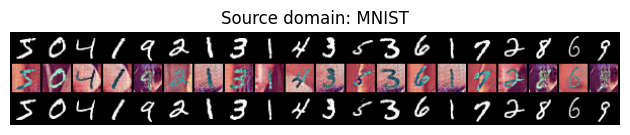

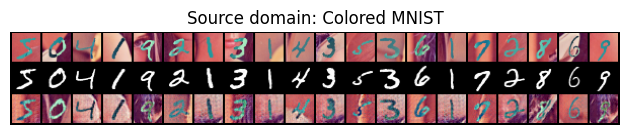

In [22]:
q4_save_results(q4)